# 06 · Comparación de transfer learning

Reúne los runs de las 5 arquitecturas (`01`-`05`), compara accuracy/macro-F1
sobre `test`, promueve el mejor modelo (el que sirve `streamlit_app.py`) y lo
deja marcado como docente para las notebooks de destilación (`07`-`09`).

In [1]:
import os
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
    os.chdir(ROOT)

print("Raíz del proyecto:", ROOT)

Raíz del proyecto: /Users/cristiansandoval/Universidad/Semillero/ButterflyModeling


In [2]:
import pandas as pd

from scripts import modelRegistry as registro
from scripts.vizStyle import SERIE_1, SERIE_2, applyStyle

ARQUITECTURAS = [
    "mobilenet_v3_small",
    "efficientnet_v2_b0",
    "resnet50_v2",
    "densenet121",
    "inception_v3",
]

## 1 · Runs más recientes por arquitectura

Si una arquitectura se entrenó más de una vez, se toma el run más reciente
(`registro.listRuns()` ya viene ordenado de más nuevo a más viejo).

In [3]:
runs = registro.listRuns()
mejorRunPorArquitectura = {}
for run in runs:
    arq = run.get("architecture")
    if arq in ARQUITECTURAS and arq not in mejorRunPorArquitectura:
        mejorRunPorArquitectura[arq] = run

faltantes = [a for a in ARQUITECTURAS if a not in mejorRunPorArquitectura]
if faltantes:
    print("Sin run registrado todavía:", faltantes)

comparacion = pd.DataFrame(mejorRunPorArquitectura.values())
comparacion = comparacion[[
    "architecture", "run_id", "epochs_ran", "training_minutes",
    "test_accuracy", "test_macro_f1", "validate_accuracy", "validate_macro_f1",
]].sort_values("test_macro_f1", ascending=False).reset_index(drop=True)
comparacion

,architecture,run_id,epochs_ran,training_minutes,test_accuracy,test_macro_f1,validate_accuracy,validate_macro_f1
0,efficientnet_v2_b0,20260902T015532Z_efficientnet-v2-b0,41,183.6,0.814258,0.802046,0.816956,0.813700
1,resnet50_v2,20260904T023029Z_resnet50-v2,50,449.7,0.792919,0.787120,0.794798,0.794264
2,densenet121,20260905T020047Z_densenet121,50,494.7,0.793404,0.784358,0.781310,0.770131
3,mobilenet_v3_small,20260902T005147Z_mobilenet-v3-small,50,60.9,0.776431,0.769148,0.772640,0.770287
4,inception_v3,20260906T040431Z_inception-v3,50,412.7,0.724054,0.710476,0.715800,0.703993


## 2 · Accuracy y macro-F1 por arquitectura

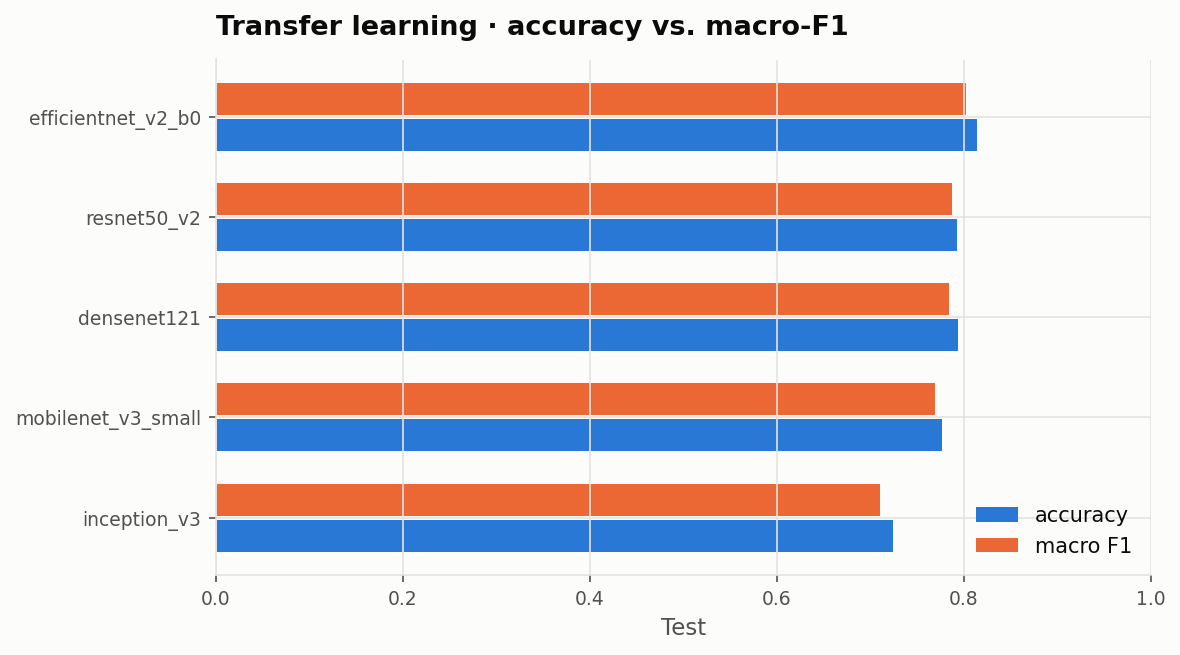

In [4]:
applyStyle()
import matplotlib.pyplot as plt

orden = comparacion.sort_values("test_macro_f1")
y = range(len(orden))

fig, ax = plt.subplots(figsize=(8, 0.6 * len(orden) + 1.5))
ax.barh([i - 0.18 for i in y], orden["test_accuracy"], height=0.32, color=SERIE_1, label="accuracy")
ax.barh([i + 0.18 for i in y], orden["test_macro_f1"], height=0.32, color=SERIE_2, label="macro F1")
ax.set_yticks(list(y), orden["architecture"])
ax.set(xlim=(0, 1), xlabel="Test", title="Transfer learning · accuracy vs. macro-F1")
ax.legend(loc="lower right")
fig.tight_layout()
plt.show()

## 3 · Mejor modelo

Se promueve por `test_macro_f1` (más informativo que accuracy con clases
desbalanceadas) y queda registrado como el docente de referencia para KD.

In [5]:
mejorArquitectura = comparacion.iloc[0]["architecture"]
mejorRun = mejorRunPorArquitectura[mejorArquitectura]

registro.promoteRun(mejorRun["run_id"])

registro.writeJson(registro.OUTPUTS_DIR / "teacher.json", {
    "run_id": mejorRun["run_id"],
    "architecture": mejorArquitectura,
    "test_accuracy": mejorRun["test_accuracy"],
    "test_macro_f1": mejorRun["test_macro_f1"],
})

print(f"Mejor arquitectura: {mejorArquitectura}")
print(f"Run promovido y marcado como docente: {mejorRun['run_id']}")

Run promovido: 20260902T015532Z_efficientnet-v2-b0
Mejor arquitectura: efficientnet_v2_b0
Run promovido y marcado como docente: 20260902T015532Z_efficientnet-v2-b0


## Resumen

In [6]:
comparacion

,architecture,run_id,epochs_ran,training_minutes,test_accuracy,test_macro_f1,validate_accuracy,validate_macro_f1
0,efficientnet_v2_b0,20260902T015532Z_efficientnet-v2-b0,41,183.6,0.814258,0.802046,0.816956,0.813700
1,resnet50_v2,20260904T023029Z_resnet50-v2,50,449.7,0.792919,0.787120,0.794798,0.794264
2,densenet121,20260905T020047Z_densenet121,50,494.7,0.793404,0.784358,0.781310,0.770131
3,mobilenet_v3_small,20260902T005147Z_mobilenet-v3-small,50,60.9,0.776431,0.769148,0.772640,0.770287
4,inception_v3,20260906T040431Z_inception-v3,50,412.7,0.724054,0.710476,0.715800,0.703993
